In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("data.csv")
df.head

<bound method NDFrame.head of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

         

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df["name"].fillna("Unknown", inplace=True)

df["host_name"].fillna("Unknown", inplace=True)

df["reviews_per_month"].fillna(df["reviews_per_month"].mean(), inplace=True)

C:\Users\Sai\AppData\Local\Temp\ipykernel_20656\3557053471.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["name"].fillna("Unknown", inplace=True)
C:\Users\Sai\AppData\Local\Temp\ipykernel_20656\3557053471.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an 

0        0.210000
1        0.380000
2        1.373221
3        4.640000
4        0.100000
           ...   
48890    1.373221
48891    1.373221
48892    1.373221
48893    1.373221
48894    1.373221
Name: reviews_per_month, Length: 48895, dtype: float64

In [8]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

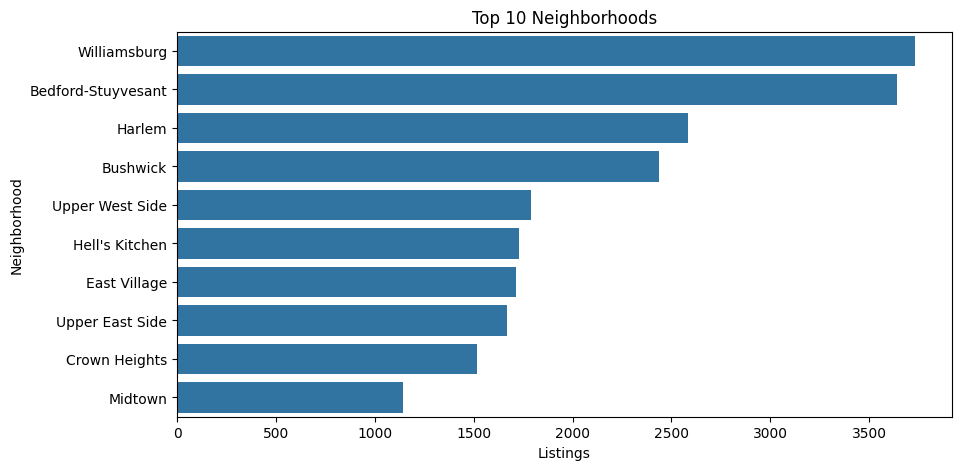

In [9]:
top_neigh = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_neigh.values, y=top_neigh.index)

plt.title("Top 10 Neighborhoods")
plt.xlabel("Listings")
plt.ylabel("Neighborhood")
plt.show()

In [14]:
df.drop_duplicates(inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_17792\3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


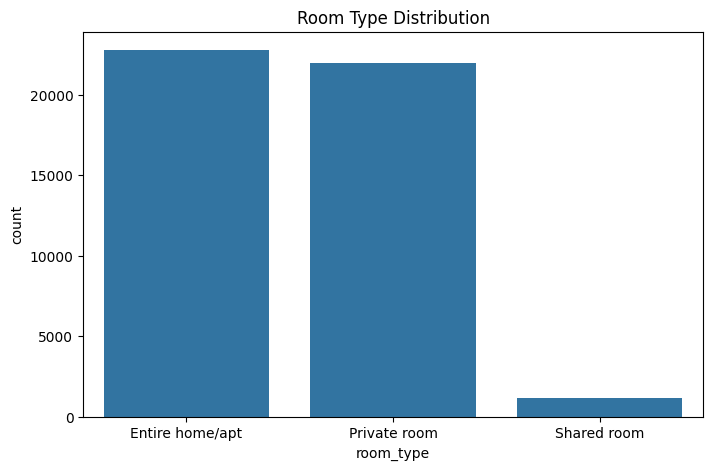

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='room_type',
              order=df['room_type'].value_counts().index)

plt.title("Room Type Distribution")
plt.show()

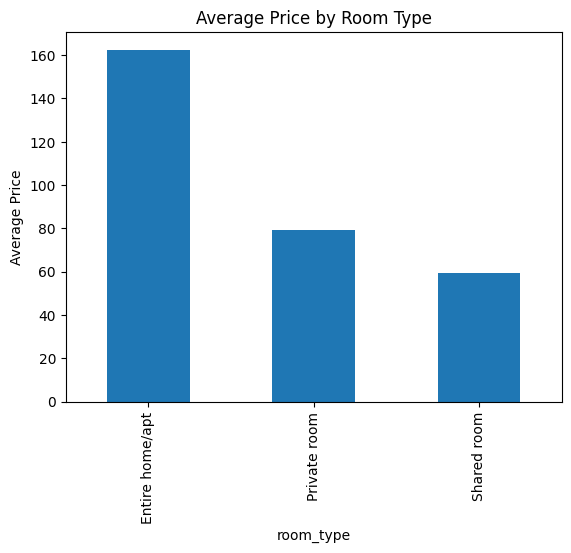

In [11]:
avg_price = df.groupby('room_type')['price'].mean()

avg_price.plot(kind='bar')

plt.title("Average Price by Room Type")
plt.ylabel("Average Price")
plt.show()

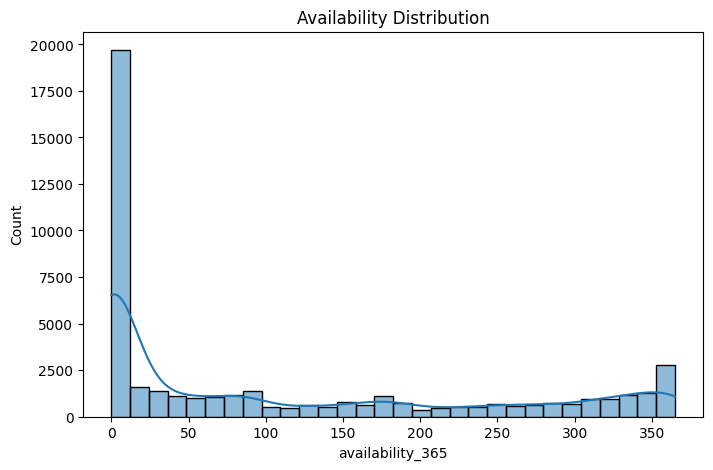

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['availability_365'],
             bins=30,
             kde=True)

plt.title("Availability Distribution")
plt.show()

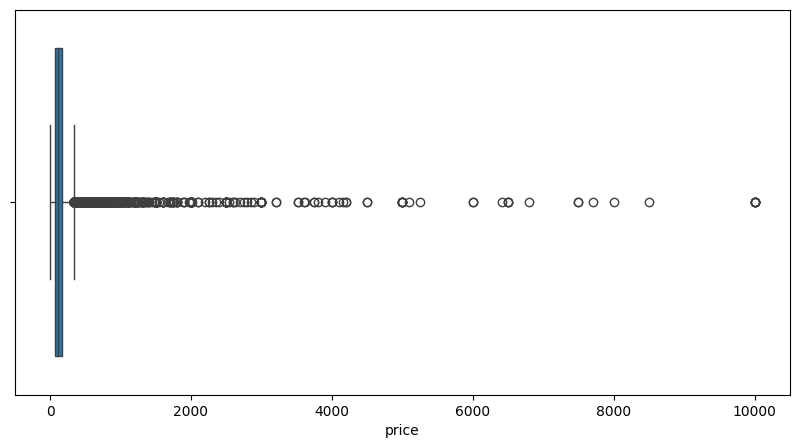

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["price"])

plt.show()

In [7]:
df.to_csv("cleaned_data.csv", index=False)

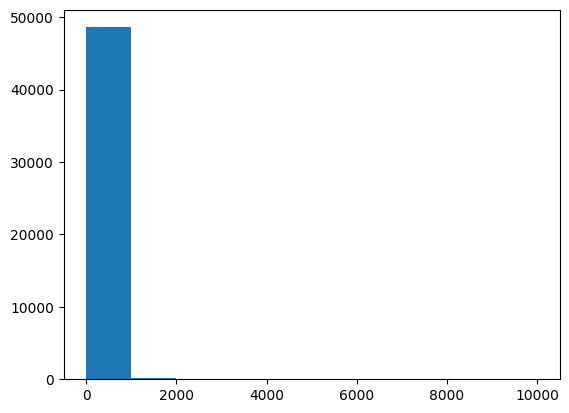

In [12]:
plt.hist(df["price"])

plt.show()

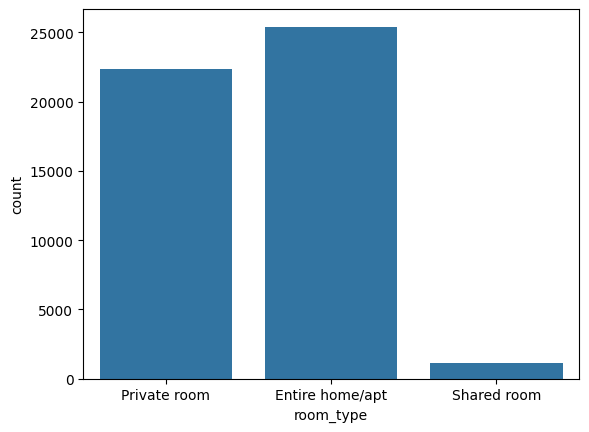

In [13]:
sns.countplot(x="room_type", data=df)

plt.show()

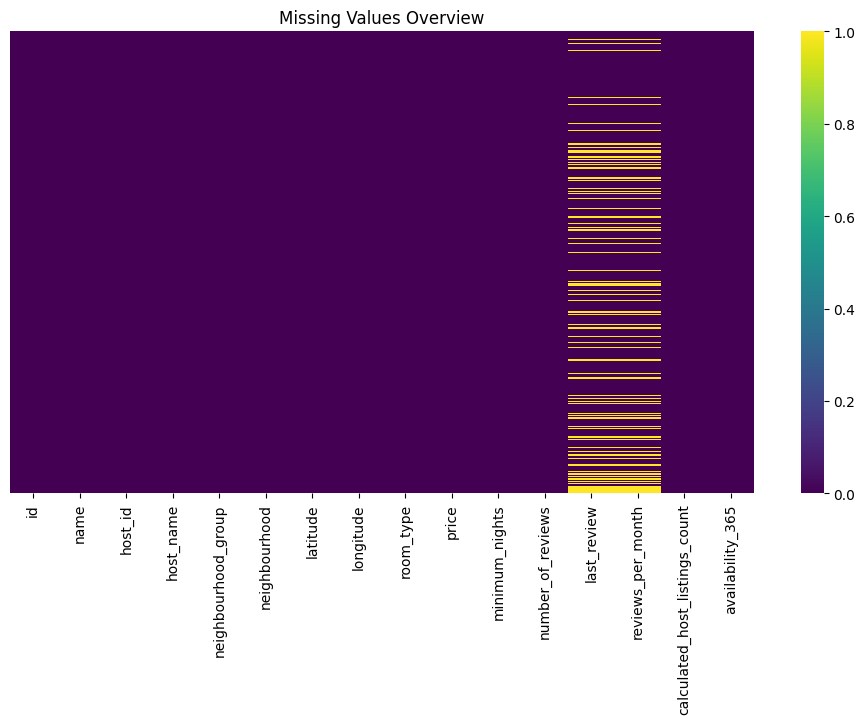

In [13]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=True,
    cmap="viridis"
)

plt.title("Missing Values Overview")
plt.show()